# Algoritmo genético para optimización de hiperparámetros
**Actividad 02 | Cuaderno revisado, autónomo y compatible con Google Colab.**

Buscamos una buena configuración de `RandomForestClassifier` para Wine (178 muestras,
13 variables, 3 clases). El AG optimiza hiperparámetros; los árboles se entrenan normalmente.
Ejecuta **Entorno de ejecución > Ejecutar todas** en un entorno nuevo, sin GPU ni archivos externos.
Reservamos 20 % para prueba; la selección usa exclusivamente CV estratificada de 3 pliegues
sobre el 80 % de desarrollo. La exactitud CV del ganador es una métrica de selección, no de prueba.


In [1]:
# En Colab esto ya suele estar instalado. Si falta:
# %pip install -q scikit-learn matplotlib numpy

In [2]:
import random
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

data = load_wine()
X, y = data.data, data.target
print(f"Wine: {X.shape[0]} muestras, {X.shape[1]} features, {len(set(y))} clases")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
idx_dev, idx_test = train_test_split(np.arange(len(y)), test_size=0.20, stratify=y, random_state=SEED)
X_dev, y_dev = X[idx_dev], y[idx_dev]
X_test, y_test = X[idx_test], y[idx_test]
assert set(idx_dev).isdisjoint(idx_test)
print(f"Desarrollo: {len(y_dev)} | Prueba reservada: {len(y_test)}")


Wine: 178 muestras, 13 features, 3 clases
Desarrollo: 142 | Prueba reservada: 36


## 1. Cromosoma = hiperparámetros

El espacio de búsqueda es discreto a propósito: así el cruce y la mutación son fáciles de explicar.

In [3]:
SEARCH_SPACE = {
    "n_estimators": [20, 40, 60, 80, 100],
    "max_depth": [2, 3, 4, 5, 8, 12, None],
    "min_samples_split": [2, 3, 4, 6, 8, 10],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}
GENES = list(SEARCH_SPACE.keys())

@dataclass
class Individual:
    genes: dict
    fitness: float | None = None

    def copy(self):
        return Individual(genes=dict(self.genes), fitness=self.fitness)


def random_individual():
    return Individual({k: random.choice(v) for k, v in SEARCH_SPACE.items()})

print("Ejemplo de cromosoma:", random_individual().genes)

Ejemplo de cromosoma: {'n_estimators': 20, 'max_depth': 2, 'min_samples_split': 10, 'max_features': 'log2', 'criterion': 'gini'}


## 2. Aptitud (fitness)
Aptitud = promedio de exactitud en CV de 3 pliegues sobre **X_dev, y_dev**.
Todos los candidatos usan los mismos pliegues y semilla. Guardamos las evaluaciones
en caché para evitar entrenar otra vez un cromosoma repetido. El test queda reservado hasta el final.


In [4]:
SEED = 42
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

cache = {}

def evaluate(ind: Individual) -> float:
    key = tuple(ind.genes[g] for g in GENES)
    if key in cache:
        ind.fitness = cache[key]
        return ind.fitness
    model = RandomForestClassifier(
        n_estimators=ind.genes["n_estimators"],
        max_depth=ind.genes["max_depth"],
        min_samples_split=ind.genes["min_samples_split"],
        max_features=ind.genes["max_features"],
        criterion=ind.genes["criterion"],
        random_state=SEED,
        n_jobs=1,
    )
    scores = cross_val_score(model, X_dev, y_dev, cv=CV, error_score="raise", scoring="accuracy")
    ind.fitness = float(np.mean(scores))
    cache[key] = ind.fitness
    return ind.fitness

## 3. Operadores del ciclo: selección, cruce, mutación

- **Selección por torneo**: se eligen 3 individuos al azar; gana el de mayor fitness.
- **Cruce uniforme**: cada gen sale del padre 1 o del padre 2.
- **Mutación**: un gen cambia a otro valor válido.
- **Elitismo**: los 2 mejores pasan sin cambiar.

In [5]:
def tournament_select(pop, k=3):
    return max(random.sample(pop, k), key=lambda i: i.fitness if i.fitness is not None else -np.inf)

def crossover(p1, p2, rate=0.8):
    if random.random() > rate:
        return p1.copy(), p2.copy()
    c1, c2 = {}, {}
    for g in GENES:
        if random.random() < 0.5:
            c1[g], c2[g] = p1.genes[g], p2.genes[g]
        else:
            c1[g], c2[g] = p2.genes[g], p1.genes[g]
    return Individual(c1), Individual(c2)

def mutate(ind, rate=0.25):
    child = ind.copy()
    child.fitness = None
    for g, values in SEARCH_SPACE.items():
        if random.random() < rate:
            opts = [v for v in values if v != child.genes[g]] or values
            child.genes[g] = random.choice(opts)
    return child

## 4. Inicialización, evolución y terminación
Población aleatoria de 10 individuos; torneo de 3; cruce uniforme con probabilidad 0.8;
mutación de 0.25 por gen; 2 élites. Se realizan **6 transiciones generacionales**.
El historial incluye la población inicial (0) y la final (6). El elitismo conserva el mejor
valor observado, aunque la media de la población puede bajar. No garantiza el óptimo global.


In [6]:
def run_ga(pop_size=10, generations=6, elite=2, seed=SEED):
    assert pop_size >= 3 and 0 < elite < pop_size and generations >= 0
    cache.clear()
    random.seed(seed)
    np.random.seed(seed)

    pop = [random_individual() for _ in range(pop_size)]
    for ind in pop:
        evaluate(ind)

    history = []
    for gen in range(generations):
        ranked = sorted(pop, key=lambda i: i.fitness if i.fitness is not None else -np.inf, reverse=True)
        history.append({
            "gen": gen,
            "best": ranked[0].fitness,
            "mean": float(np.mean([i.fitness for i in pop])),
            "worst": ranked[-1].fitness,
            "genes": dict(ranked[0].genes),
        })
        print(f"Gen {gen:02d}  mejor={ranked[0].fitness:.4f}  media={history[-1]['mean']:.4f}  {ranked[0].genes}")

        next_pop = [i.copy() for i in ranked[:elite]]  # elitismo
        while len(next_pop) < pop_size:
            p1, p2 = tournament_select(pop), tournament_select(pop)
            c1, c2 = crossover(p1, p2)
            next_pop.append(mutate(c1))
            if len(next_pop) < pop_size:
                next_pop.append(mutate(c2))
        pop = next_pop[:pop_size]
        for ind in pop:
            if ind.fitness is None:
                evaluate(ind)

    ranked = sorted(pop, key=lambda i: i.fitness if i.fitness is not None else -np.inf, reverse=True)
    history.append({
        "gen": generations,
        "best": ranked[0].fitness,
        "mean": float(np.mean([i.fitness for i in pop])),
        "worst": ranked[-1].fitness,
        "genes": dict(ranked[0].genes),
    })
    print(f"FINAL     mejor={ranked[0].fitness:.4f}  {ranked[0].genes}")
    return ranked[0], history

best, history = run_ga()

Gen 00  mejor=0.9511  media=0.9234  {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'max_features': 'sqrt', 'criterion': 'gini'}


Gen 01  mejor=0.9511  media=0.9320  {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'max_features': 'sqrt', 'criterion': 'gini'}


Gen 02  mejor=0.9580  media=0.9454  {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}


Gen 03  mejor=0.9580  media=0.9404  {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}


Gen 04  mejor=0.9580  media=0.9468  {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}


Gen 05  mejor=0.9580  media=0.9482  {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}


FINAL     mejor=0.9580  {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}


## 5. Visualización del ciclo

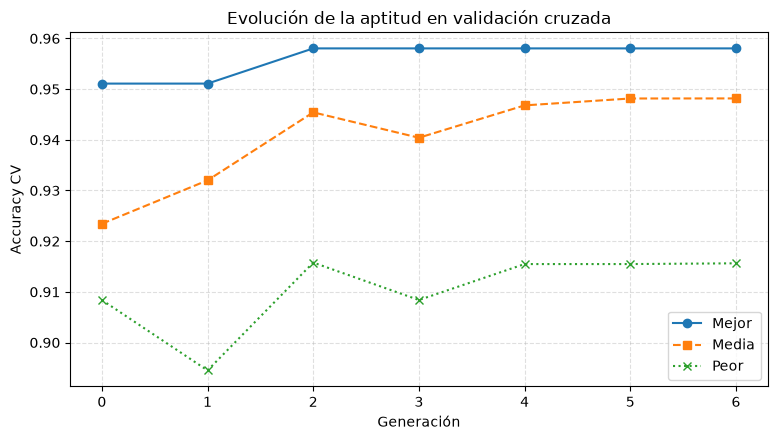

Mejor cromosoma: {'n_estimators': 80, 'max_depth': 12, 'min_samples_split': 3, 'max_features': 'log2', 'criterion': 'entropy'}
Aptitud: 95.8038%


In [7]:
gens = [h["gen"] for h in history]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(gens, [h["best"] for h in history], "o-", label="Mejor")
ax.plot(gens, [h["mean"] for h in history], "s--", label="Media")
ax.plot(gens, [h["worst"] for h in history], "x:", label="Peor")
ax.set_xlabel("Generación")
ax.set_ylabel("Accuracy CV")
ax.set_title("Evolución de la aptitud en validación cruzada")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Mejor cromosoma:", best.genes)
print(f"Aptitud: {best.fitness:.4%}")

## 6. Comparación con una referencia y prueba final
Referencia fijada antes de evaluar el test: Random Forest con parámetros predeterminados.
Entrenamos referencia y ganador en todo desarrollo y evaluamos una vez en el test reservado.
El resultado puede empatar o empeorar frente a la referencia: una búsqueda pequeña no garantiza mejoras.


In [8]:
referencia = RandomForestClassifier(random_state=SEED, n_jobs=1)
referencia_cv = float(cross_val_score(referencia, X_dev, y_dev, cv=CV, scoring='accuracy', error_score='raise').mean())
referencia.fit(X_dev, y_dev)
modelo_final = RandomForestClassifier(**best.genes, random_state=SEED, n_jobs=1)
modelo_final.fit(X_dev, y_dev)
base_test = float(referencia.score(X_test, y_test))
ag_test = float(modelo_final.score(X_test, y_test))
assert all(history[i+1]['best'] >= history[i]['best'] - 1e-12 for i in range(len(history)-1))
resultado = {'ejemplo': 'Hiperparámetros', 'semilla': SEED, 'n_desarrollo': len(y_dev),
             'n_test': len(y_test), 'referencia_cv': referencia_cv, 'mejor_cv': best.fitness,
             'referencia_test': base_test, 'ag_test': ag_test, 'ganador': best.genes,
             'evaluaciones_unicas': len(cache), 'historial': history}
print(f'Referencia: CV={referencia_cv:.2%}, test={base_test:.2%}')
print(f'AG: CV={best.fitness:.2%}, test={ag_test:.2%}')


Referencia: CV=95.11%, test=100.00%
AG: CV=95.80%, test=100.00%


## 7. Exportar resultados reproducibles


In [9]:
import json, platform
from pathlib import Path
import sklearn, matplotlib
resultado['versiones'] = {'python': platform.python_version(), 'numpy': np.__version__,
                         'scikit_learn': sklearn.__version__, 'matplotlib': matplotlib.__version__}
Path('resultados').mkdir(exist_ok=True)
ruta = Path('resultados/hiperparametros.json')
ruta.write_text(json.dumps(resultado, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(resultado, ensure_ascii=False, indent=2))
print('Resultado guardado en:', ruta)


{
  "ejemplo": "Hiperparámetros",
  "semilla": 42,
  "n_desarrollo": 142,
  "n_test": 36,
  "referencia_cv": 0.9510933806146573,
  "mejor_cv": 0.9580378250591016,
  "referencia_test": 1.0,
  "ag_test": 1.0,
  "ganador": {
    "n_estimators": 80,
    "max_depth": 12,
    "min_samples_split": 3,
    "max_features": "log2",
    "criterion": "entropy"
  },
  "evaluaciones_unicas": 47,
  "historial": [
    {
      "gen": 0,
      "best": 0.9510933806146573,
      "mean": 0.9234338061465721,
      "worst": 0.9083924349881797,
      "genes": {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_split": 2,
        "max_features": "sqrt",
        "criterion": "gini"
      }
    },
    {
      "gen": 1,
      "best": 0.9510933806146573,
      "mean": 0.9320035460992907,
      "worst": 0.8945035460992908,
      "genes": {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_split": 2,
        "max_features": "sqrt",
        "criterion": "gini"
      }
  

## Para explicar en la evaluación oral
1. Un cromosoma contiene cinco decisiones: número de árboles, profundidad, mínimo para dividir,
   variables por división y criterio de impureza.
2. Torneo, cruce y mutación proponen nuevas configuraciones; el elitismo conserva las mejores.
3. La búsqueda termina tras seis generaciones, sin usar el test para elegir.
4. La mutación favorece explorar, pero no evita siempre el estancamiento.
5. Diferencia entre **CV de selección** y **test final**; no afirmar que el mejor candidato sea el óptimo global.

Referencia: [validación cruzada de scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html).
